# Notebook 4. SAM-based fusion and Sentinel-2 calibration

This notebook extends `notebook_3.ipynb` with a full **Spectral Angle Mapper (SAM)** workflow.
The key assumption is that the spectral library from `dataset/merged.csv` is the calibration target.

Workflow:
1. load the spectral library and build class medians,
2. sample the library at the common airborne / Sentinel-2 wavelengths,
3. download Sentinel-2 L2A data for each airborne cube,
4. classify airborne and Sentinel pixels with SAM,
5. fit a **band-wise linear calibration** for Sentinel-2 using class anchors from `merged.csv`,
6. compare raw vs calibrated Sentinel-2 against the airborne reference for **all HDR files available in `data/`**.




In [25]:
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import spectral.io.envi as envi
import planetary_computer
import pystac_client
import rasterio
from pyproj import CRS, Transformer
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds, transform as window_transform
from rasterio.warp import reproject

DATA_DIR = Path("data")
LIBRARY_PATH = Path("dataset/merged.csv")
HDR_FILES = sorted(DATA_DIR.glob("*.hdr"))

CATALOG_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
SENTINEL_COLLECTION = "sentinel-2-l2a"
SENTINEL_DATE_RANGE = "2022-01-01/2022-12-31"
MAX_CLOUD_COVER = 20
SEARCH_LIMIT = 12
MIN_CLASS_PIXELS = 200

BAND_SPECS = [
    ("blue", 490.0, "B02"),
    ("green", 560.0, "B03"),
    ("red", 665.0, "B04"),
    ("red_edge", 705.0, "B05"),
    ("nir", 842.0, "B08"),
]
BAND_NAMES = [name for name, _, _ in BAND_SPECS]
COMMON_WAVELENGTHS = np.array([wavelength for _, wavelength, _ in BAND_SPECS], dtype=np.float32)
SENTINEL_ASSETS = {name: asset for name, _, asset in BAND_SPECS}

PREFERRED_CLASSES = ["water", "polluted_water", "grass", "forest", "crops"]
CLASS_COLORS = {
    "water": "#1f78b4",
    "polluted_water": "#6a3d9a",
    "grass": "#33a02c",
    "forest": "#0b6623",
    "crops": "#ffb000",
}

if not HDR_FILES:
    raise FileNotFoundError(f"No .hdr files found in {DATA_DIR.resolve()}")

print("HDR files:")
for hdr in HDR_FILES:
    print(" -", hdr.name)


HDR files:
 - 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
 - 221000_Odra_HS_Blok_A_013_VS_join_atm.hdr
 - 221000_Odra_HS_Blok_A_015_VS_join_atm.hdr


In [26]:
def load_library(path):
    with path.open(newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        header = next(reader)
        wavelengths = np.array([float(value) for value in header[1:]], dtype=np.float32)
        grouped = {}
        for row in reader:
            grouped.setdefault(row[0], []).append(np.array(row[1:], dtype=np.float32))

    samples = {label: np.vstack(rows) for label, rows in grouped.items()}
    medians = {label: np.nanmedian(values, axis=0) for label, values in samples.items()}
    return wavelengths, samples, medians


def sample_signature(source_wavelengths, signature, target_wavelengths):
    indices = [int(np.argmin(np.abs(source_wavelengths - target))) for target in target_wavelengths]
    return signature[indices]


def build_anchor_matrix(source_wavelengths, medians, labels, target_wavelengths):
    return np.vstack([
        sample_signature(source_wavelengths, medians[label], target_wavelengths)
        for label in labels
    ]).astype(np.float32)


def robust_stretch(channel):
    finite = np.isfinite(channel)
    if not finite.any():
        return np.zeros_like(channel, dtype=np.float32)
    p2, p98 = np.nanpercentile(channel[finite], [2, 98])
    return np.clip((channel - p2) / max(p98 - p2, 1e-6), 0, 1)


def compose_rgb_from_cube(cube, rgb_indices=(0, 1, 2)):
    rgb = cube[:, :, list(rgb_indices)].astype(np.float32)
    out = np.zeros_like(rgb, dtype=np.float32)
    for idx in range(3):
        out[:, :, idx] = robust_stretch(rgb[:, :, idx])
    return np.nan_to_num(out, nan=0.0)


def parse_wavelengths(meta):
    raw = meta.get("wavelength")
    if raw is None:
        return None
    return np.array([float(value) for value in raw], dtype=np.float32)


def get_ignore_value(meta):
    raw = meta.get("data ignore value")
    if raw is None:
        return None
    return float(str(raw).strip())


def nearest_band_index(wavelengths, target_nm, nbands):
    if wavelengths is None or len(wavelengths) != nbands:
        return int(np.clip(round((target_nm - 450.0) / (900.0 - 450.0) * (nbands - 1)), 0, nbands - 1))
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def meta_as_text(value):
    if isinstance(value, (list, tuple)):
        return ", ".join(str(part).strip() for part in value if str(part).strip())
    return str(value).strip()


def meta_as_int(value):
    return int(float(meta_as_text(value)))


def meta_as_float(value):
    return float(meta_as_text(value))


def parse_default_bands(value):
    if value is None:
        return [74, 45, 18]
    if isinstance(value, (list, tuple)):
        parts = value
    else:
        parts = str(value).strip().strip("{}").split(",")
    bands = [int(float(part)) - 1 for part in parts[:3]]
    return bands if len(bands) == 3 else [74, 45, 18]


def parse_map_info(meta):
    raw = meta.get("map info")
    parts = raw if isinstance(raw, (list, tuple)) else str(raw).strip().strip("{}").split(",")
    parts = [str(part).strip() for part in parts]
    return {
        "x_ul": meta_as_float(parts[3]),
        "y_ul": meta_as_float(parts[4]),
        "pixel_width": meta_as_float(parts[5]),
        "pixel_height": meta_as_float(parts[6]),
    }


def envi_transform(meta):
    info = parse_map_info(meta)
    x_min = info["x_ul"] - 0.5 * info["pixel_width"]
    y_max = info["y_ul"] + 0.5 * info["pixel_height"]
    return rasterio.Affine.translation(x_min, y_max) * rasterio.Affine.scale(info["pixel_width"], -info["pixel_height"])


def envi_bounds(meta):
    info = parse_map_info(meta)
    samples = meta_as_int(meta["samples"])
    lines = meta_as_int(meta["lines"])
    x_min = info["x_ul"] - 0.5 * info["pixel_width"]
    y_max = info["y_ul"] + 0.5 * info["pixel_height"]
    x_max = x_min + samples * info["pixel_width"]
    y_min = y_max - lines * info["pixel_height"]
    return (x_min, y_min, x_max, y_max)


def lonlat_bounds(bounds, src_crs):
    xs = [bounds[0], bounds[0], bounds[2], bounds[2]]
    ys = [bounds[1], bounds[3], bounds[1], bounds[3]]
    lon, lat = Transformer.from_crs(src_crs, "EPSG:4326", always_xy=True).transform(xs, ys)
    return (min(lon), min(lat), max(lon), max(lat))


def read_airborne_rgb(img):
    meta = img.metadata
    ignore_value = get_ignore_value(meta)
    scale = float(meta.get("reflectance scale factor", 10000.0))
    indices = parse_default_bands(meta.get("default bands"))
    cube = img.read_bands(indices).astype(np.float32)
    if ignore_value is not None:
        cube[cube == ignore_value] = np.nan
    cube[cube < 0] = np.nan
    cube /= scale
    return compose_rgb_from_cube(cube, (0, 1, 2))


def read_airborne_common_cube(img, target_wavelengths):
    meta = img.metadata
    wavelengths = parse_wavelengths(meta)
    ignore_value = get_ignore_value(meta)
    scale = float(meta.get("reflectance scale factor", 10000.0))
    indices = [nearest_band_index(wavelengths, wavelength, img.nbands) for wavelength in target_wavelengths]
    cube = img.read_bands(indices).astype(np.float32)
    if ignore_value is not None:
        cube[cube == ignore_value] = np.nan
    cube[cube < 0] = np.nan
    cube /= scale
    selected_wavelengths = wavelengths[indices] if wavelengths is not None else np.array(indices, dtype=np.float32)
    return cube, selected_wavelengths


In [27]:
def select_best_item(items):
    return sorted(
        items,
        key=lambda item: (
            float(item.properties.get("eo:cloud_cover", 100.0) or 100.0),
            -(item.datetime.timestamp() if item.datetime else 0.0),
        ),
    )[0]


def read_sentinel_cube(item, bbox_lonlat):
    arrays = []
    with rasterio.open(item.assets[SENTINEL_ASSETS["red"]].href) as ref_src:
        ref_bounds = Transformer.from_crs("EPSG:4326", ref_src.crs, always_xy=True).transform_bounds(
            *map(float, bbox_lonlat))
        ref_window = from_bounds(*ref_bounds, ref_src.transform).round_offsets().round_lengths()
        ref_transform = window_transform(ref_window, ref_src.transform)
        ref_height = int(ref_window.height)
        ref_width = int(ref_window.width)

        for label in BAND_NAMES:
            asset_name = SENTINEL_ASSETS[label]
            with rasterio.open(item.assets[asset_name].href) as src:
                with WarpedVRT(
                        src,
                        crs=ref_src.crs,
                        transform=ref_transform,
                        height=ref_height,
                        width=ref_width,
                        resampling=Resampling.bilinear,
                ) as vrt:
                    arrays.append(vrt.read(1).astype(np.float32) / 10000.0)

    cube = np.stack(arrays, axis=-1)
    cube[cube < 0] = np.nan
    return cube, ref_transform, ref_src.crs


def reproject_cube(src_cube, src_transform, src_crs, dst_transform, dst_crs, dst_shape, resampling=Resampling.bilinear):
    dst = np.zeros((src_cube.shape[-1], dst_shape[0], dst_shape[1]), dtype=np.float32)
    reproject(
        source=np.moveaxis(src_cube, -1, 0),
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=resampling,
    )
    return np.moveaxis(dst, 0, -1)


def reproject_labels(src_labels, src_transform, src_crs, dst_transform, dst_crs, dst_shape):
    dst = np.full(dst_shape, -1, dtype=np.int16)
    reproject(
        source=src_labels.astype(np.int16),
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        src_nodata=-1,
        dst_nodata=-1,
        resampling=Resampling.nearest,
    )
    return dst


In [28]:
def valid_mask(cube):
    finite = np.isfinite(cube).all(axis=-1)
    safe_cube = np.where(np.isfinite(cube), cube, -np.inf)
    return finite & (np.max(safe_cube, axis=-1) > 1e-6)


def sam_classify_cube(cube, anchors):
    h, w, bands = cube.shape
    flat = cube.reshape(-1, bands)
    finite = np.isfinite(flat).all(axis=1)
    safe_flat = np.where(np.isfinite(flat), flat, -np.inf)
    valid = finite & (np.max(safe_flat, axis=1) > 1e-6)

    label_map = np.full(flat.shape[0], -1, dtype=np.int16)
    angle_map = np.full(flat.shape[0], np.nan, dtype=np.float32)

    if valid.any():
        spectra = flat[valid]
        spectra_norm = spectra / np.maximum(np.linalg.norm(spectra, axis=1, keepdims=True), 1e-6)
        anchor_norm = anchors / np.maximum(np.linalg.norm(anchors, axis=1, keepdims=True), 1e-6)
        cos_theta = np.clip(spectra_norm @ anchor_norm.T, -1.0, 1.0)
        angles = np.arccos(cos_theta).astype(np.float32)
        best_idx = np.argmin(angles, axis=1)
        best_angle = angles[np.arange(angles.shape[0]), best_idx]
        label_map[valid] = best_idx.astype(np.int16)
        angle_map[valid] = best_angle

    return label_map.reshape(h, w), angle_map.reshape(h, w)


def pairwise_sam_map(cube_a, cube_b, mask):
    dot_product = np.sum(cube_a * cube_b, axis=-1)
    norm_a = np.linalg.norm(cube_a, axis=-1)
    norm_b = np.linalg.norm(cube_b, axis=-1)
    cos_theta = np.divide(dot_product, norm_a * norm_b + 1e-9)
    sam = np.arccos(np.clip(cos_theta, -1.0, 1.0)).astype(np.float32)
    sam[~mask] = np.nan
    return sam


def fit_bandwise_calibration(sentinel_cube, reference_labels, anchor_matrix, labels, mask, min_pixels=MIN_CLASS_PIXELS):
    coeffs = []
    rows = []

    for band_idx, band_name in enumerate(BAND_NAMES):
        x = []
        y = []
        support = {}

        for class_idx, label in enumerate(labels):
            class_mask = mask & (reference_labels == class_idx) & np.isfinite(sentinel_cube[:, :, band_idx])
            count = int(class_mask.sum())
            if count >= min_pixels:
                x.append(float(np.nanmedian(sentinel_cube[:, :, band_idx][class_mask])))
                y.append(float(anchor_matrix[class_idx, band_idx]))
                support[label] = count

        if len(x) >= 2:
            slope, intercept = np.polyfit(np.array(x), np.array(y), 1)
            fitted = slope * np.array(x) + intercept
            ss_res = float(np.sum((np.array(y) - fitted) ** 2))
            ss_tot = float(np.sum((np.array(y) - np.mean(y)) ** 2))
            r2 = np.nan if ss_tot <= 1e-12 else 1.0 - ss_res / ss_tot
        elif len(x) == 1:
            slope = 1.0
            intercept = y[0] - x[0]
            r2 = np.nan
        else:
            slope = 1.0
            intercept = 0.0
            r2 = np.nan

        coeffs.append((float(slope), float(intercept)))
        rows.append({
            "band": band_name,
            "slope": float(slope),
            "intercept": float(intercept),
            "r2": float(r2) if np.isfinite(r2) else np.nan,
            "classes_used": len(x),
            "support": support,
        })

    return np.array(coeffs, dtype=np.float32), rows


def apply_calibration(cube, coeffs):
    calibrated = cube.copy()
    for band_idx, (slope, intercept) in enumerate(coeffs):
        calibrated[:, :, band_idx] = np.clip(calibrated[:, :, band_idx] * slope + intercept, 0.0, 1.5)
    return calibrated


def classification_agreement(predicted, reference, mask):
    valid = mask & (reference >= 0) & (predicted >= 0)
    if not valid.any():
        return np.nan, 0
    return float(np.mean(predicted[valid] == reference[valid])), int(valid.sum())


def format_calibration_rows(rows):
    print("band        slope    intercept     R2   classes  support")
    for row in rows:
        support = ", ".join(f"{label}:{count}" for label, count in row["support"].items()) or "-"
        r2 = f"{row['r2']:.3f}" if np.isfinite(row["r2"]) else "n/a"
        print(
            f"{row['band']:<10} {row['slope']:>7.3f} {row['intercept']:>11.4f} {r2:>6} {row['classes_used']:>8}  {support}")


def make_class_cmap(labels):
    return ListedColormap([CLASS_COLORS[label] for label in labels])


def plot_label_map(ax, label_map, labels, cmap, title):
    masked = np.ma.masked_less(label_map, 0)
    ax.imshow(masked, cmap=cmap, vmin=-0.5, vmax=len(labels) - 0.5)
    ax.set_title(title, fontsize=11)
    ax.axis("off")


## 1. Load the spectral library from `merged.csv`

The library is created in `notebook_2.ipynb` by merging all exported point signatures.
Here we turn it into:
- a **median spectrum** for each class,
- a reduced **5-band anchor matrix** for the common airborne / Sentinel-2 wavelengths.


Classes used for SAM and calibration:
 - water: 10 signatures
 - polluted_water: 8 signatures
 - grass: 7 signatures
 - forest: 13 signatures
 - crops: 6 signatures


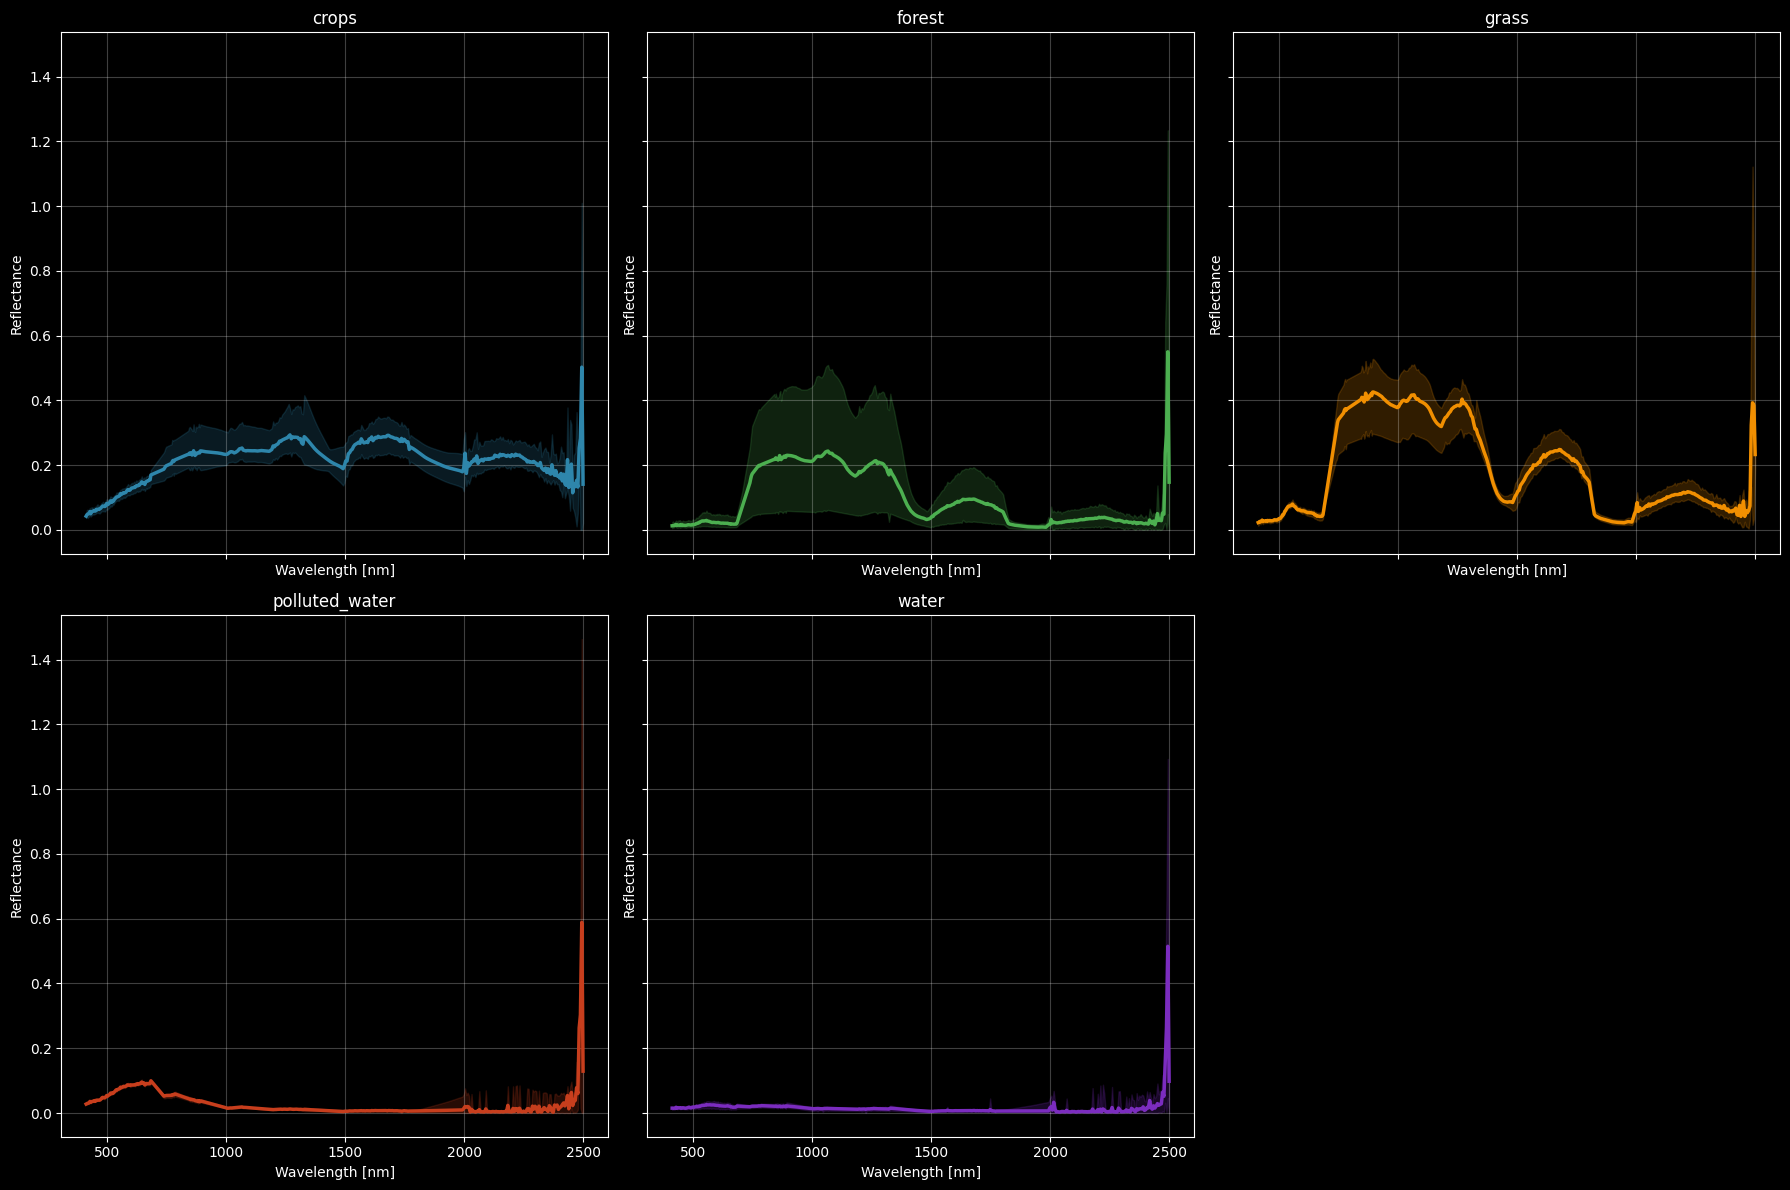

In [29]:
library_wavelengths, library_samples, library_medians = load_library(LIBRARY_PATH)
class_labels = [label for label in PREFERRED_CLASSES if label in library_medians]
library_anchors = build_anchor_matrix(library_wavelengths, library_medians, class_labels, COMMON_WAVELENGTHS)
class_cmap = make_class_cmap(class_labels)

print("Classes used for SAM and calibration:")
for label in class_labels:
    print(f" - {label}: {library_samples[label].shape[0]} signatures")

colors = ["#2E86AB", "#4CAF50", "#F18F01", "#C73E1D", "#7B2CBF", "#00897B"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

for ax, label, color in zip(axes, sorted(class_labels), colors):
    class_array = library_samples[label]
    mean_values = class_array.mean(axis=0)
    min_values = class_array.min(axis=0)
    max_values = class_array.max(axis=0)

    ax.plot(library_wavelengths, mean_values, color=color, linewidth=2.5)
    ax.fill_between(library_wavelengths, min_values, max_values, color=color, alpha=0.2)
    ax.set_title(label)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("Reflectance")

for ax in axes[len(class_labels):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 2. SAM pipeline for every airborne cube

For each `hdr` file the notebook will:
- open the airborne cube and extract the 5 common bands,
- download the best Sentinel-2 scene covering the airborne AOI,
- classify the airborne cube with SAM,
- reproject the airborne labels to the Sentinel grid,
- fit the Sentinel calibration using `merged.csv` class anchors,
- compare raw vs calibrated Sentinel-2 with both **class agreement** and **pairwise SAM**.


221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
Sentinel item: S2B_MSIL2A_20220719T095559_R122_T33UYR_20220719T221254
Cloud cover: 0.000409
Airborne wavelengths used: 490.9 nm, 561.2 nm, 663.5 nm, 705.0 nm, 842.5 nm
Overlap pixels for evaluation: 30516
band        slope    intercept     R2   classes  support
blue         0.415     -0.0233  0.096        5  water:2177, polluted_water:3737, grass:7909, forest:11872, crops:4821
green        0.500     -0.0171  0.076        5  water:2177, polluted_water:3737, grass:7909, forest:11872, crops:4821
red          0.924     -0.0770  0.278        5  water:2177, polluted_water:3737, grass:7909, forest:11872, crops:4821
red_edge     0.889     -0.0717  0.227        5  water:2177, polluted_water:3737, grass:7909, forest:11872, crops:4821
nir          0.990     -0.1242  0.569        5  water:2177, polluted_water:3737, grass:7909, forest:11872, crops:4821
Class agreement raw/calibrated: 0.244 -> 0.571
Median pairwise SAM raw/calibrated [rad]: 0.2990 -> 0.1105


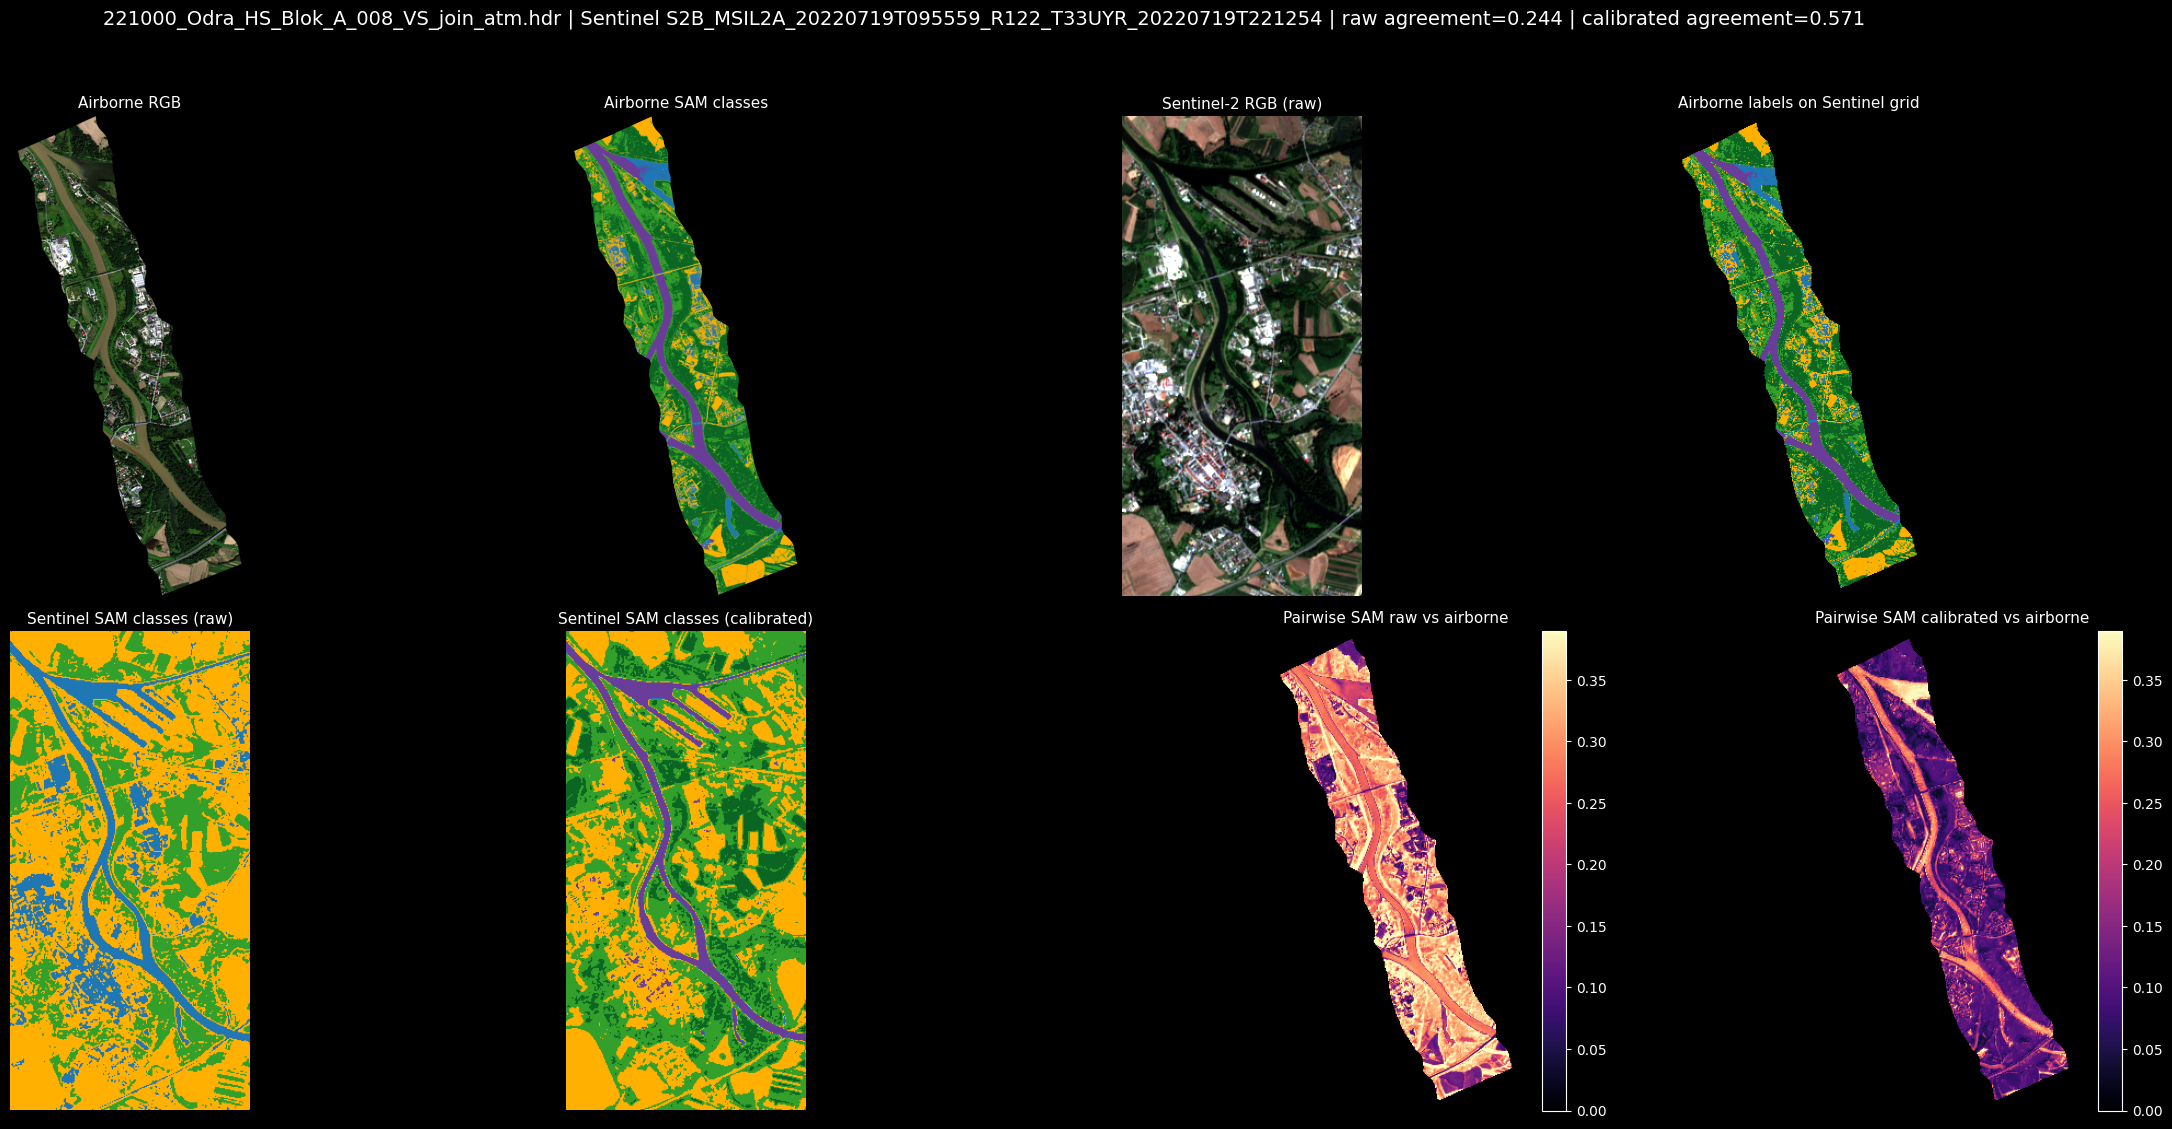

221000_Odra_HS_Blok_A_013_VS_join_atm.hdr
Sentinel item: S2B_MSIL2A_20220719T095559_R122_T33UYR_20220719T221254
Cloud cover: 0.000409
Airborne wavelengths used: 490.9 nm, 561.2 nm, 663.5 nm, 705.0 nm, 842.5 nm
Overlap pixels for evaluation: 31015
band        slope    intercept     R2   classes  support
blue         1.936     -0.2241  0.958        4  water:2823, grass:10909, forest:15149, crops:2123
green        2.181     -0.2600  0.907        4  water:2823, grass:10909, forest:15149, crops:2123
red          2.227     -0.2499  0.993        4  water:2823, grass:10909, forest:15149, crops:2123
red_edge     2.548     -0.3360  0.902        4  water:2823, grass:10909, forest:15149, crops:2123
nir          1.289     -0.1605  0.648        4  water:2823, grass:10909, forest:15149, crops:2123
Class agreement raw/calibrated: 0.170 -> 0.610
Median pairwise SAM raw/calibrated [rad]: 0.3654 -> 0.1111


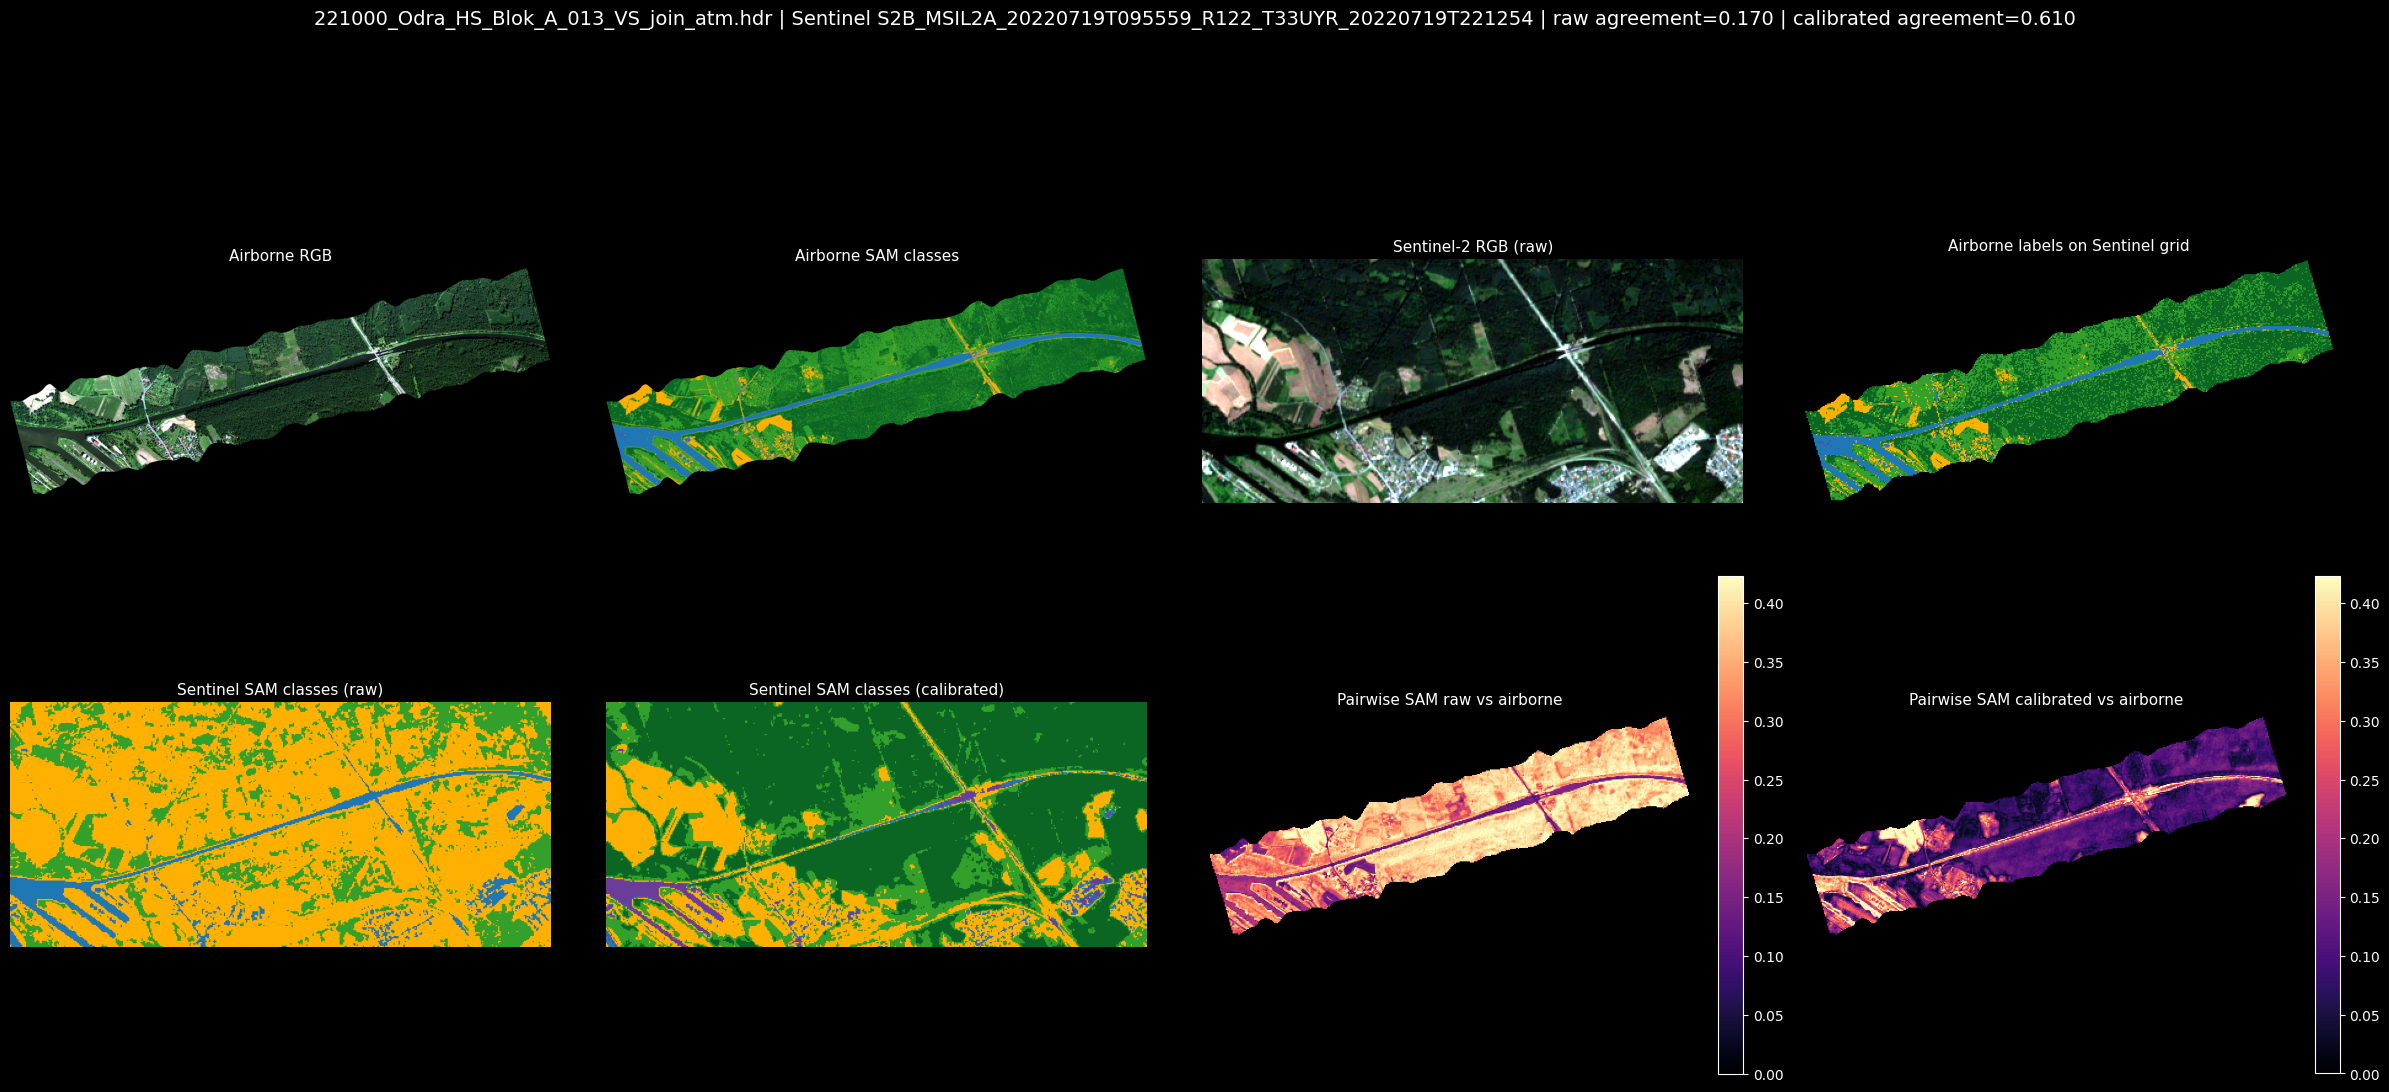

221000_Odra_HS_Blok_A_015_VS_join_atm.hdr
Sentinel item: S2B_MSIL2A_20220719T095559_R122_T33UYR_20220719T221254
Cloud cover: 0.000409
Airborne wavelengths used: 490.9 nm, 561.2 nm, 663.5 nm, 705.0 nm, 842.5 nm
Overlap pixels for evaluation: 29461
band        slope    intercept     R2   classes  support
blue         1.348     -0.1540  0.993        4  water:3827, grass:9187, forest:12306, crops:4126
green        1.761     -0.2150  0.988        4  water:3827, grass:9187, forest:12306, crops:4126
red          1.912     -0.2213  0.991        4  water:3827, grass:9187, forest:12306, crops:4126
red_edge     2.207     -0.3103  0.997        4  water:3827, grass:9187, forest:12306, crops:4126
nir          1.476     -0.2710  0.601        4  water:3827, grass:9187, forest:12306, crops:4126
Class agreement raw/calibrated: 0.259 -> 0.593
Median pairwise SAM raw/calibrated [rad]: 0.3210 -> 0.1710


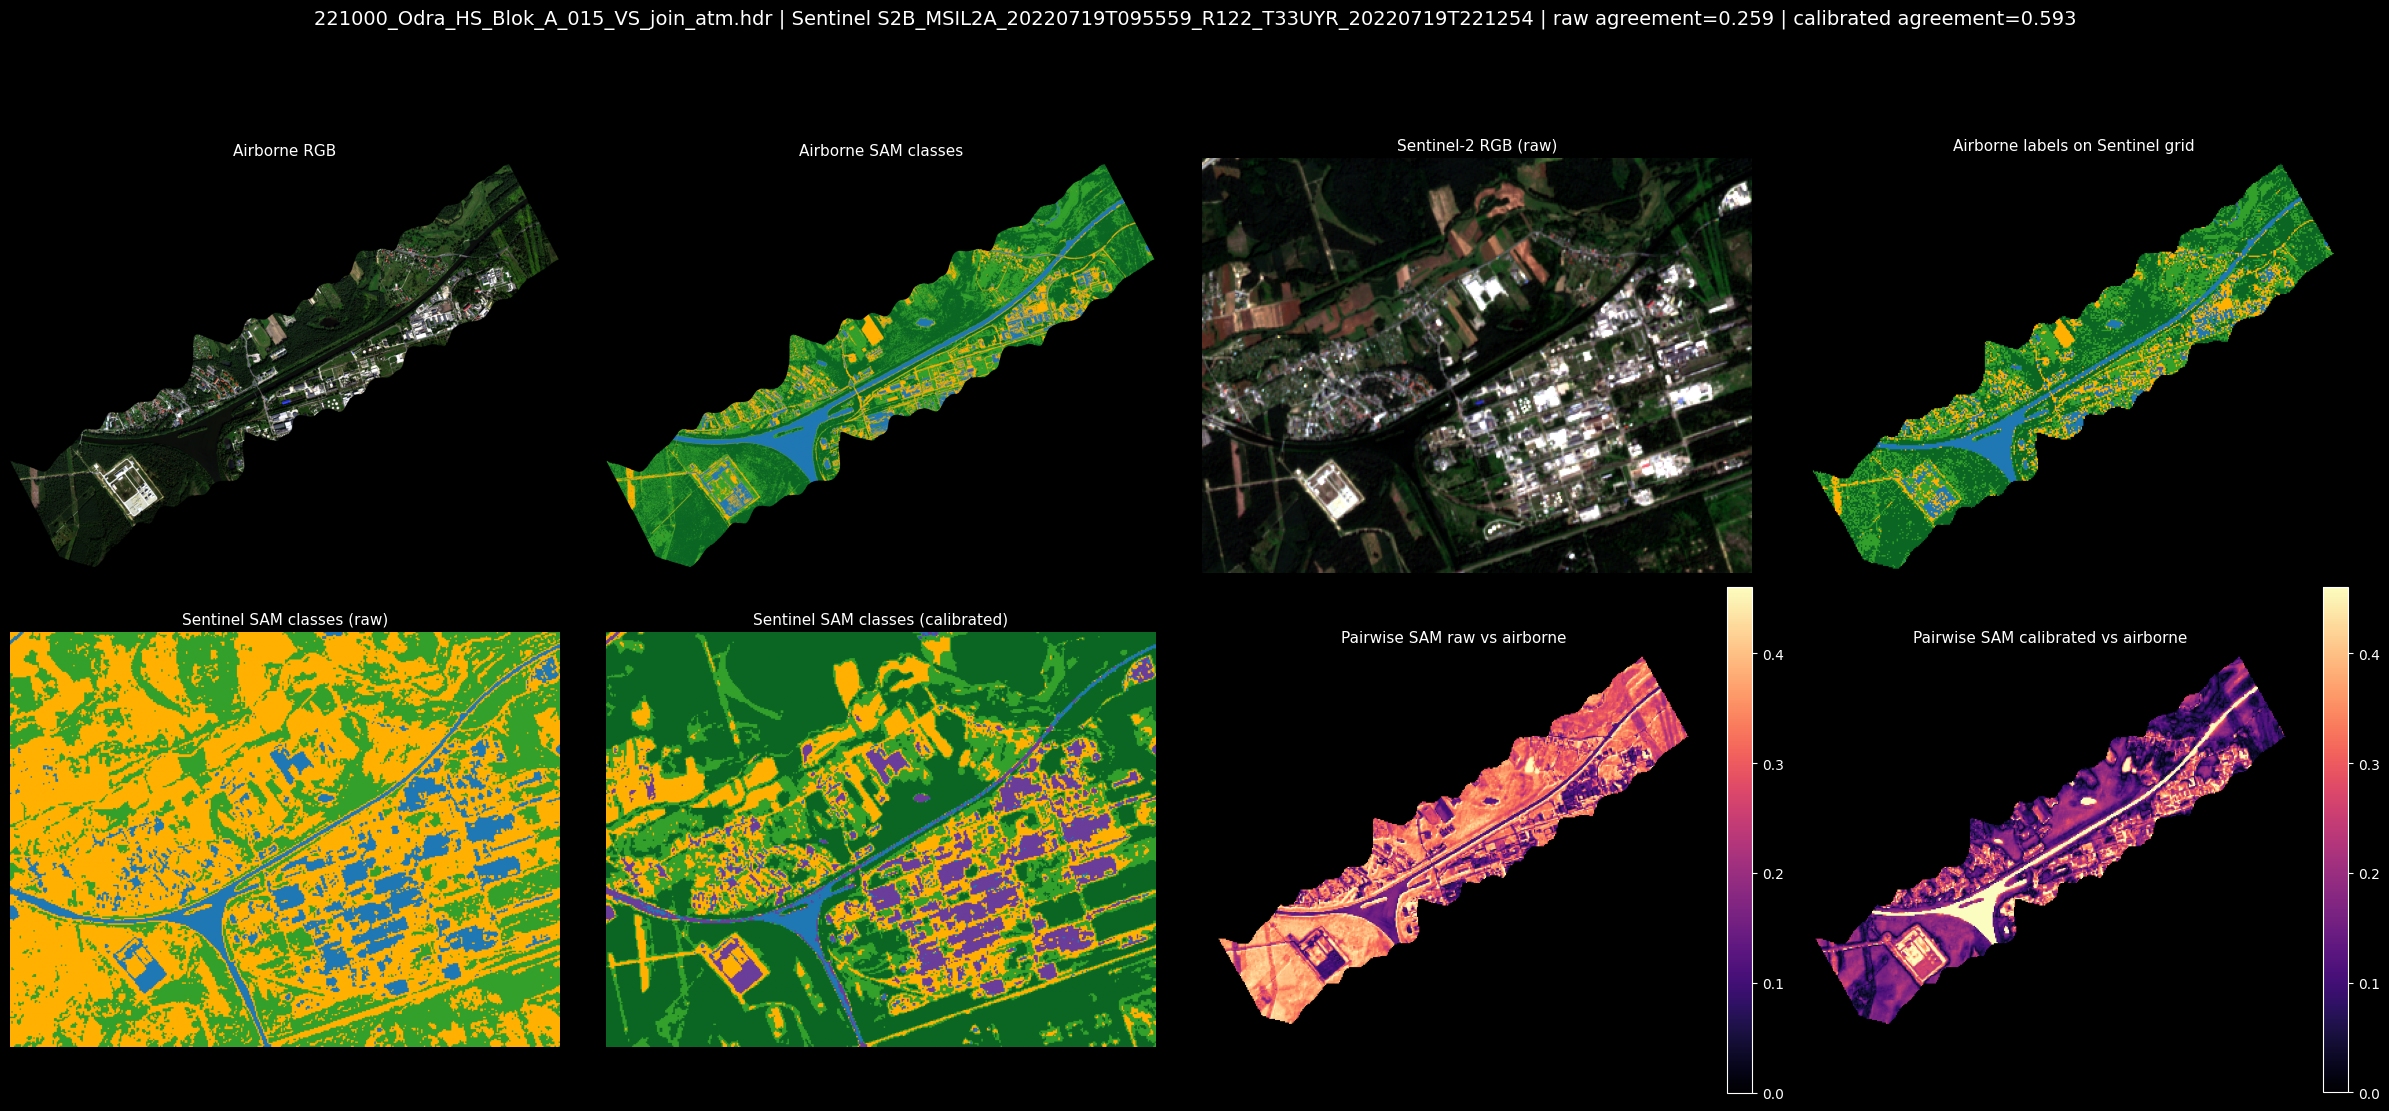

In [30]:
catalog = pystac_client.Client.open(CATALOG_URL, modifier=planetary_computer.sign_inplace)

for hdr in HDR_FILES:
    print("=" * 100)
    print(hdr.name)

    img = envi.open(str(hdr))
    meta = img.metadata
    src_crs = CRS.from_wkt(meta_as_text(meta["coordinate system string"]))
    src_transform = envi_transform(meta)
    bbox_lonlat = lonlat_bounds(envi_bounds(meta), src_crs)

    airborne_rgb = read_airborne_rgb(img)
    airborne_cube, airborne_selected_wavelengths = read_airborne_common_cube(img, COMMON_WAVELENGTHS)
    airborne_labels, _ = sam_classify_cube(airborne_cube, library_anchors)

    items = list(catalog.search(
        collections=[SENTINEL_COLLECTION],
        bbox=bbox_lonlat,
        datetime=SENTINEL_DATE_RANGE,
        query={"eo:cloud_cover": {"lt": MAX_CLOUD_COVER}},
        limit=SEARCH_LIMIT,
    ).items())
    if not items:
        raise RuntimeError(f"No Sentinel-2 items found for {hdr.name}")

    item = select_best_item(items)
    sentinel_cube, sentinel_transform, sentinel_crs = read_sentinel_cube(item, bbox_lonlat)
    sentinel_rgb = compose_rgb_from_cube(sentinel_cube, (2, 1, 0))

    airborne_on_sentinel = reproject_cube(
        airborne_cube,
        src_transform,
        src_crs,
        sentinel_transform,
        sentinel_crs,
        sentinel_cube.shape[:2],
    )
    airborne_labels_on_sentinel = reproject_labels(
        airborne_labels,
        src_transform,
        src_crs,
        sentinel_transform,
        sentinel_crs,
        sentinel_cube.shape[:2],
    )

    overlap_mask = valid_mask(airborne_on_sentinel) & valid_mask(sentinel_cube) & (airborne_labels_on_sentinel >= 0)
    coefficients, calibration_rows = fit_bandwise_calibration(
        sentinel_cube,
        airborne_labels_on_sentinel,
        library_anchors,
        class_labels,
        overlap_mask,
    )
    sentinel_calibrated = apply_calibration(sentinel_cube, coefficients)

    sentinel_labels_raw, _ = sam_classify_cube(sentinel_cube, library_anchors)
    sentinel_labels_cal, _ = sam_classify_cube(sentinel_calibrated, library_anchors)

    pairwise_raw = pairwise_sam_map(sentinel_cube, airborne_on_sentinel, overlap_mask)
    pairwise_cal = pairwise_sam_map(sentinel_calibrated, airborne_on_sentinel, overlap_mask)

    raw_agreement, overlap_pixels = classification_agreement(sentinel_labels_raw, airborne_labels_on_sentinel,
                                                             overlap_mask)
    cal_agreement, _ = classification_agreement(sentinel_labels_cal, airborne_labels_on_sentinel, overlap_mask)

    print(f"Sentinel item: {item.id}")
    print(f"Cloud cover: {item.properties.get('eo:cloud_cover', 'n/a')}")
    print("Airborne wavelengths used:", ", ".join(f"{value:.1f} nm" for value in airborne_selected_wavelengths))
    print(f"Overlap pixels for evaluation: {overlap_pixels}")
    format_calibration_rows(calibration_rows)
    print(
        f"Class agreement raw/calibrated: "
        f"{raw_agreement:.3f} -> {cal_agreement:.3f}"
        if np.isfinite(raw_agreement) and np.isfinite(cal_agreement)
        else "Class agreement raw/calibrated: n/a"
    )
    raw_pairwise = float(np.nanmedian(pairwise_raw)) if np.isfinite(pairwise_raw).any() else np.nan
    cal_pairwise = float(np.nanmedian(pairwise_cal)) if np.isfinite(pairwise_cal).any() else np.nan
    print(
        f"Median pairwise SAM raw/calibrated [rad]: "
        f"{raw_pairwise:.4f} -> {cal_pairwise:.4f}"
        if np.isfinite(raw_pairwise) and np.isfinite(cal_pairwise)
        else "Median pairwise SAM raw/calibrated [rad]: n/a"
    )

    pairwise_values = np.concatenate([
        pairwise_raw[np.isfinite(pairwise_raw)],
        pairwise_cal[np.isfinite(pairwise_cal)],
    ])
    pairwise_vmax = np.nanpercentile(pairwise_values, 95) if pairwise_values.size else 1.0

    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    axes[0, 0].imshow(airborne_rgb)
    axes[0, 0].set_title("Airborne RGB", fontsize=11)
    axes[0, 0].axis("off")

    plot_label_map(axes[0, 1], airborne_labels, class_labels, class_cmap, "Airborne SAM classes")
    axes[0, 2].imshow(sentinel_rgb)
    axes[0, 2].set_title("Sentinel-2 RGB (raw)", fontsize=11)
    axes[0, 2].axis("off")
    plot_label_map(axes[0, 3], airborne_labels_on_sentinel, class_labels, class_cmap,
                   "Airborne labels on Sentinel grid")

    plot_label_map(axes[1, 0], sentinel_labels_raw, class_labels, class_cmap, "Sentinel SAM classes (raw)")
    plot_label_map(axes[1, 1], sentinel_labels_cal, class_labels, class_cmap, "Sentinel SAM classes (calibrated)")
    im_raw = axes[1, 2].imshow(pairwise_raw, cmap="magma", vmin=0.0, vmax=pairwise_vmax)
    axes[1, 2].set_title("Pairwise SAM raw vs airborne", fontsize=11)
    axes[1, 2].axis("off")
    im_cal = axes[1, 3].imshow(pairwise_cal, cmap="magma", vmin=0.0, vmax=pairwise_vmax)
    axes[1, 3].set_title("Pairwise SAM calibrated vs airborne", fontsize=11)
    axes[1, 3].axis("off")

    fig.colorbar(im_raw, ax=axes[1, 2], fraction=0.046, pad=0.04)
    fig.colorbar(im_cal, ax=axes[1, 3], fraction=0.046, pad=0.04)
    fig.suptitle(
        f"{hdr.name} | Sentinel {item.id} | raw agreement={raw_agreement:.3f} | calibrated agreement={cal_agreement:.3f}"
        if np.isfinite(raw_agreement) and np.isfinite(cal_agreement)
        else f"{hdr.name} | Sentinel {item.id}",
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


## 3. Interpretation

The calibration is intentionally simple and fully traceable:
- **targets** come from `merged.csv`, not from the raw Sentinel scene,
- **support pixels** come from SAM labels extracted from the airborne cube,
- calibration is fitted **independently for each Sentinel band**.

In practice this means:
- the airborne cube provides the spatial reference,
- `merged.csv` provides the class reflectance anchors,
- Sentinel-2 is adjusted so that the medians of the visible / red-edge / NIR bands are closer to the library.
